Sessão PySpark iniciada com sucesso!

--- Estrutura dos Dados no PySpark ---
root
 |-- Cliente_ID: long (nullable = true)
 |-- Idade: long (nullable = true)
 |-- Renda_Mensal: double (nullable = true)
 |-- Tempo_Contrato_Meses: long (nullable = true)
 |-- Tipo_Contrato: string (nullable = true)
 |-- Metodo_Pagamento: string (nullable = true)
 |-- Suporte_Tecnico: string (nullable = true)
 |-- Valor_Cobrado_Mensal: double (nullable = true)
 |-- Inadimplente_Churn: long (nullable = true)


--- Taxa Geral de Inadimplência/Churn ---
Inadimplente_Churn
0    75.0
1    25.0
Name: proportion, dtype: float64


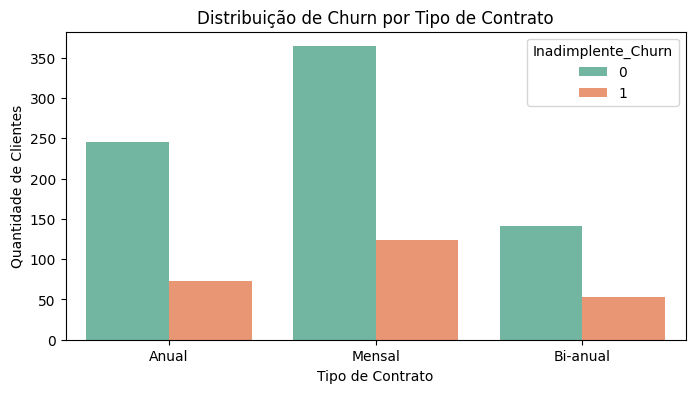


--- Métricas de Avaliação do Modelo ---
              precision    recall  f1-score   support

           0       0.77      0.95      0.85       231
           1       0.15      0.03      0.05        69

    accuracy                           0.74       300
   macro avg       0.46      0.49      0.45       300
weighted avg       0.63      0.74      0.67       300

ROC-AUC Score: 0.4474

Base exportada com sucesso: 'base_tratada_credit_churn.csv'


In [2]:
# ==========================================
# 1. INSTALAÇÃO E CONFIGURAÇÃO DO AMBIENTE
# ==========================================
!pip install pyspark -q

import pandas as np_pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, round as spark_round

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Inicializa sessão PySpark
spark = SparkSession.builder.appName("Credit_Churn_Analysis").getOrCreate()
print("Sessão PySpark iniciada com sucesso!")

# ==========================================
# 2. SIMULAÇÃO E INGESTÃO DE DADOS (RAW DATA)
# ==========================================
np.random.seed(42)
n_samples = 1000

data = {
    'Cliente_ID': range(1001, 1001 + n_samples),
    'Idade': np.random.randint(18, 70, n_samples),
    'Renda_Mensal': np.random.normal(4500, 1500, n_samples).round(2),
    'Tempo_Contrato_Meses': np.random.randint(1, 60, n_samples),
    'Tipo_Contrato': np.random.choice(['Mensal', 'Anual', 'Bi-anual'], n_samples, p=[0.5, 0.3, 0.2]),
    'Metodo_Pagamento': np.random.choice(['Boleto', 'Cartao_Credito', 'Debito_Automatico'], n_samples, p=[0.4, 0.3, 0.3]),
    'Suporte_Tecnico': np.random.choice(['Sim', 'Nao'], n_samples, p=[0.4, 0.6]),
    'Valor_Cobrado_Mensal': np.random.normal(120, 35, n_samples).round(2),
    'Inadimplente_Churn': np.random.choice([0, 1], n_samples, p=[0.73, 0.27])
}

df_pandas = np_pd.DataFrame(data)

# Converte o DataFrame Pandas para PySpark DataFrame
df_spark = spark.createDataFrame(df_pandas)
print("\n--- Estrutura dos Dados no PySpark ---")
df_spark.printSchema()

# ==========================================
# 3. TRATAMENTO, SANITIZAÇÃO E ENGENHARIA
# ==========================================
# Criando feature de Risco por Comprometimento e Faixa de Relacionamento
df_spark = df_spark.withColumn(
    "Razao_Custo_Renda",
    spark_round(col("Valor_Cobrado_Mensal") / col("Renda_Mensal"), 4)
)

df_spark = df_spark.withColumn(
    "Perfil_Tenure",
    when(col("Tempo_Contrato_Meses") <= 12, "Novato")
    .when((col("Tempo_Contrato_Meses") > 12) & (col("Tempo_Contrato_Meses") <= 36), "Pleno")
    .otherwise("Veterano")
)

# Converte de volta para Pandas para Análise Exploratória Visual (EDA)
df_clean = df_spark.toPandas()

# ==========================================
# 4. ANÁLISE EXPLORATÓRIA DE DADOS (EDA)
# ==========================================
print("\n--- Taxa Geral de Inadimplência/Churn ---")
print(df_clean['Inadimplente_Churn'].value_counts(normalize=True) * 100)

# Visualização de Churn por Tipo de Contrato
plt.figure(figsize=(8, 4))
sns.countplot(data=df_clean, x='Tipo_Contrato', hue='Inadimplente_Churn', palette='Set2')
plt.title('Distribuição de Churn por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Quantidade de Clientes')
plt.savefig('churn_por_contrato.png')
plt.show()

# ==========================================
# 5. MODELAGEM DE MACHINE LEARNING (CREDIT SCORE)
# ==========================================
# Prepara variáveis para o modelo de classificação
X = df_clean[['Idade', 'Renda_Mensal', 'Tempo_Contrato_Meses', 'Valor_Cobrado_Mensal', 'Razao_Custo_Renda']]
y = df_clean['Inadimplente_Churn']

# Divisão Treino/Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Treinamento com Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predições e Probabilidades (Credit / Churn Score)
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1]

print("\n--- Métricas de Avaliação do Modelo ---")
print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_probs), 4))

# Exporta base tratada com Score para uso no Looker Studio
df_clean['Score_Risco'] = ((1 - model.predict_proba(X)[:, 1]) * 1000).astype(int)
df_clean.to_csv('base_tratada_credit_churn.csv', index=False)
print("\nBase exportada com sucesso: 'base_tratada_credit_churn.csv'")